# EDA do dataset supervisionado do CineBot ML

Este notebook analisa a base `movie_preferences.csv`, que alimenta o treino do modelo de relevância do CineBot.

O foco aqui é a parte do dataset que realmente impacta a modelagem. Itens que não agregam para este domínio foram reduzidos ou substituídos por checagens mais úteis para recomendação de filmes.

## Escopo e premissas

- O centro da análise é a base supervisionada final, porque é ela que entra no treino do ML.
- O alvo `relevante` é um **rótulo proxy supervisionado**: ele nasce a partir de um score heurístico de afinidade e depois pode ser sobrescrito por feedback real do usuário.
- Algumas colunas existem por motivos operacionais, mas **não devem entrar no modelo**: `movie_id`, `titulo`, `poster`, `url` e `score_heuristico`.
- Como o problema é de classificação binária com desbalanceamento, a EDA precisa sustentar a escolha de métricas além de accuracy.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 120)

candidate_paths = [
    Path("datasets/movie_preferences.csv"),
    Path("../datasets/movie_preferences.csv"),
]
DATASET_PATH = next((path for path in candidate_paths if path.exists()), None)
assert DATASET_PATH is not None, "Arquivo datasets/movie_preferences.csv não encontrado."

print(f"Dataset localizado em: {DATASET_PATH.resolve()}")

Dataset localizado em: /home/gf307/Documentos/axacademy/desafios/botcity_movie_bot/datasets/movie_preferences.csv


## 1. Carregamento e inspeção inicial

A primeira etapa confirma o tamanho da base, mostra exemplos de linhas e valida se os tipos de dados fazem sentido para o problema.

In [2]:
df = pd.read_csv(DATASET_PATH)

print(f"Shape: {df.shape[0]:,} linhas x {df.shape[1]} colunas".replace(",", "."))
display(df.head())
display(df.sample(3, random_state=42))

Shape: 176.400 linhas x 37 colunas


,movie_id,titulo,sinopse,genero,generos_texto,diretor,ano,nota,votos,duracao,streaming_count,release_period,poster,url,sinopse_word_count,keyword_count,secondary_genre_count,has_streaming,has_poster,pref_1,pref_2,pref_3,decade_pref,popularity_pref,ranked_profile_text,primary_match_pref_1,secondary_match_pref_2,secondary_match_pref_3,ranked_match_count,genre_overlap_count,matches_decade_pref,popular_score,hidden_gem_score,matches_popularity_pref,popularity_match_score,score_heuristico,relevante
0,155,Batman: O Cavaleiro das Trevas,Batman: O Cavaleiro das Trevas Após dois anos ...,acao,Ação Suspense,Christopher Nolan,2008,8.5,35866,152,4,anos_2000,https://image.tmdb.org/t/p/w500/4lj1ikfsSmMZNy...,https://www.themoviedb.org/movie/155?language=...,58,6,3,1,1,acao,comedia,drama,moderno,popular,Ação Ação Ação Ação Ação Comédia Comédia Drama...,1,0,0,1,1,0,0.955,0.3825,1,0.9550,0.7255,1
1,155,Batman: O Cavaleiro das Trevas,Batman: O Cavaleiro das Trevas Após dois anos ...,acao,Ação Suspense,Christopher Nolan,2008,8.5,35866,152,4,anos_2000,https://image.tmdb.org/t/p/w500/4lj1ikfsSmMZNy...,https://www.themoviedb.org/movie/155?language=...,58,6,3,1,1,acao,comedia,drama,moderno,joia_escondida,Ação Ação Ação Ação Ação Comédia Comédia Drama...,1,0,0,1,1,0,0.955,0.3825,0,0.3825,0.6683,1
2,155,Batman: O Cavaleiro das Trevas,Batman: O Cavaleiro das Trevas Após dois anos ...,acao,Ação Suspense,Christopher Nolan,2008,8.5,35866,152,4,anos_2000,https://image.tmdb.org/t/p/w500/4lj1ikfsSmMZNy...,https://www.themoviedb.org/movie/155?language=...,58,6,3,1,1,acao,comedia,drama,anos_2000,popular,Ação Ação Ação Ação Ação Comédia Comédia Drama...,1,0,0,1,1,1,0.955,0.3825,1,0.9550,0.8255,1
3,155,Batman: O Cavaleiro das Trevas,Batman: O Cavaleiro das Trevas Após dois anos ...,acao,Ação Suspense,Christopher Nolan,2008,8.5,35866,152,4,anos_2000,https://image.tmdb.org/t/p/w500/4lj1ikfsSmMZNy...,https://www.themoviedb.org/movie/155?language=...,58,6,3,1,1,acao,comedia,drama,anos_2000,joia_escondida,Ação Ação Ação Ação Ação Comédia Comédia Drama...,1,0,0,1,1,1,0.955,0.3825,0,0.3825,0.7683,1
4,155,Batman: O Cavaleiro das Trevas,Batman: O Cavaleiro das Trevas Após dois anos ...,acao,Ação Suspense,Christopher Nolan,2008,8.5,35866,152,4,anos_2000,https://image.tmdb.org/t/p/w500/4lj1ikfsSmMZNy...,https://www.themoviedb.org/movie/155?language=...,58,6,3,1,1,acao,comedia,drama,antes_2000,popular,Ação Ação Ação Ação Ação Comédia Comédia Drama...,1,0,0,1,1,0,0.955,0.3825,1,0.9550,0.7255,1


,movie_id,titulo,sinopse,genero,generos_texto,diretor,ano,nota,votos,duracao,streaming_count,release_period,poster,url,sinopse_word_count,keyword_count,secondary_genre_count,has_streaming,has_poster,pref_1,pref_2,pref_3,decade_pref,popularity_pref,ranked_profile_text,primary_match_pref_1,secondary_match_pref_2,secondary_match_pref_3,ranked_match_count,genre_overlap_count,matches_decade_pref,popular_score,hidden_gem_score,matches_popularity_pref,popularity_match_score,score_heuristico,relevante
3725,346,Os Sete Samurais,Os Sete Samurais Um bando de bandidos aterrori...,acao,Ação Drama,Akira Kurosawa,1954,8.4,4240,207,1,antes_2000,https://image.tmdb.org/t/p/w500/2f3Aw6GCzpn1qw...,https://www.themoviedb.org/movie/346?language=...,44,6,2,1,1,suspense,scifi,acao,antes_2000,joia_escondida,Suspense Suspense Suspense Suspense Suspense F...,0,0,1,1,1,1,0.7149,0.5858,1,0.5858,0.3386,0
59666,769,Os Bons Companheiros,Os Bons Companheiros A história real de Henry ...,drama,Drama,Martin Scorsese,1990,8.5,14391,146,4,antes_2000,https://image.tmdb.org/t/p/w500/sTReXuaND1AjkX...,https://www.themoviedb.org/movie/769?language=...,39,6,2,1,1,drama,terror,suspense,anos_2000,popular,Drama Drama Drama Drama Drama Terror Terror Su...,1,0,0,1,1,0,0.8577,0.4682,1,0.8577,0.7158,1
88922,578,Tubarão,Tubarão Um terrível ataque a banhistas é o sin...,terror,Suspense Terror,Steven Spielberg,1975,7.7,11544,124,3,antes_2000,https://image.tmdb.org/t/p/w500/iD2XVowFgHngYG...,https://www.themoviedb.org/movie/578?language=...,68,6,3,1,1,scifi,acao,comedia,anos_2000,popular,Ficção Científica Ficção Científica Ficção Cie...,0,0,0,0,0,0,0.7929,0.4698,1,0.7929,0.1593,0


In [3]:
print("Informações gerais da base:")
df.info()

print("\nTipos por coluna:")
display(df.dtypes.to_frame("dtype"))

print("\nDescribe completo:")
display(df.describe(include="all").transpose())

Informações gerais da base:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 176400 entries, 0 to 176399
Data columns (total 37 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   movie_id                 176400 non-null  int64  
 1   titulo                   176400 non-null  object 
 2   sinopse                  176400 non-null  object 
 3   genero                   176400 non-null  object 
 4   generos_texto            176400 non-null  object 
 5   diretor                  176400 non-null  object 
 6   ano                      176400 non-null  int64  
 7   nota                     176400 non-null  float64
 8   votos                    176400 non-null  int64  
 9   duracao                  176400 non-null  int64  
 10  streaming_count          176400 non-null  int64  
 11  release_period           176400 non-null  object 
 12  poster                   176400 non-null  object 
 13  url                      176400

,dtype
movie_id,int64
titulo,object
sinopse,object
genero,object
generos_texto,object
diretor,object
ano,int64
nota,float64
votos,int64
duracao,int64



Describe completo:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
movie_id,176400.0,NaN,NaN,NaN,202906.057143,341541.794866,13.0,518.25,8264.5,325265.25,1356039.0
titulo,176400,140,Batman: O Cavaleiro das Trevas,1260,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sinopse,176400,140,Batman: O Cavaleiro das Trevas Após dois anos ...,1260,NaN,NaN,NaN,NaN,NaN,NaN,NaN
genero,176400,7,acao,25200,NaN,NaN,NaN,NaN,NaN,NaN,NaN
generos_texto,176400,32,Drama,18900,NaN,NaN,NaN,NaN,NaN,NaN,NaN
diretor,176400,104,Alfred Hitchcock,8820,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ano,176400.0,NaN,NaN,NaN,1992.778571,26.406532,1921.0,1974.75,1999.0,2016.0,2026.0
nota,176400.0,NaN,NaN,NaN,8.089286,0.2944,7.5,7.9,8.1,8.3,8.7
votos,176400.0,NaN,NaN,NaN,9380.921429,9488.277809,312.0,1789.0,6174.0,14334.75,39953.0
duracao,176400.0,NaN,NaN,NaN,127.171429,31.206302,53.0,107.75,124.0,141.0,275.0


### Leitura da inspeção inicial

- Os tipos principais estão coerentes: identificadores e textos ficaram como `object`, métricas e contagens como `int64`/`float64`, e o alvo `relevante` como inteiro binário.
- Não há indício de erro clássico de tipagem, como número salvo como string ou data numérica tratada como texto.
- O dataset já nasce em formato tabular pronto para a pipeline supervisionada, mas mistura colunas de treino com colunas de apoio operacional.
- Por isso, antes da modelagem vale separar os papéis das colunas.

In [4]:
role_map = {
    "id_operacional": ["movie_id", "titulo", "poster", "url"],
    "texto": ["sinopse", "ranked_profile_text", "generos_texto"],
    "categorica": ["genero", "pref_1", "pref_2", "pref_3", "decade_pref", "popularity_pref", "release_period", "diretor"],
    "numerica": [
        "ano", "nota", "votos", "duracao", "streaming_count", "sinopse_word_count", "keyword_count",
        "secondary_genre_count", "has_streaming", "has_poster", "primary_match_pref_1", "secondary_match_pref_2",
        "secondary_match_pref_3", "ranked_match_count", "genre_overlap_count", "matches_decade_pref",
        "popular_score", "hidden_gem_score", "matches_popularity_pref", "popularity_match_score"
    ],
    "auxiliar_nao_usar_no_treino": ["score_heuristico"],
    "alvo": ["relevante"],
}

rows = []
for papel, cols in role_map.items():
    for col in cols:
        rows.append({"coluna": col, "papel": papel})

roles_df = pd.DataFrame(rows).sort_values(["papel", "coluna"]).reset_index(drop=True)
display(roles_df)

,coluna,papel
0,relevante,alvo
1,score_heuristico,auxiliar_nao_usar_no_treino
2,decade_pref,categorica
3,diretor,categorica
4,genero,categorica
5,popularity_pref,categorica
6,pref_1,categorica
7,pref_2,categorica
8,pref_3,categorica
9,release_period,categorica


## 2. Distribuição da variável-alvo

Como o problema é de classificação, o comportamento da classe `relevante` precisa ser entendido antes de comparar modelos e métricas.

,quantidade,percentual
relevante,,
0,152512,86.46
1,23888,13.54


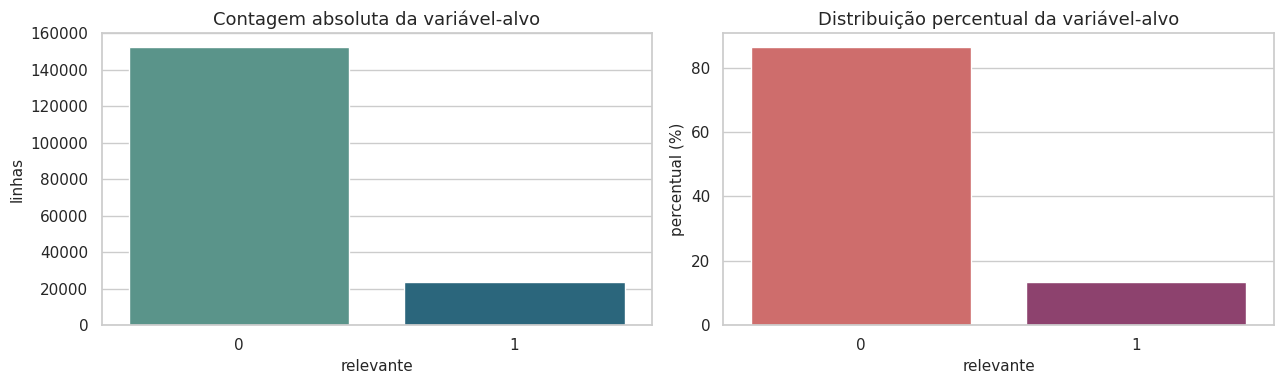

In [5]:
target_counts = df["relevante"].value_counts().sort_index()
target_pct = (df["relevante"].value_counts(normalize=True).sort_index() * 100).round(2)
target_summary = pd.DataFrame({
    "quantidade": target_counts,
    "percentual": target_pct,
})
display(target_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.countplot(data=df, x="relevante", ax=axes[0], palette="crest")
axes[0].set_title("Contagem absoluta da variável-alvo")
axes[0].set_xlabel("relevante")
axes[0].set_ylabel("linhas")

sns.barplot(x=target_summary.index.astype(str), y=target_summary["percentual"], ax=axes[1], palette="flare")
axes[1].set_title("Distribuição percentual da variável-alvo")
axes[1].set_xlabel("relevante")
axes[1].set_ylabel("percentual (%)")

plt.tight_layout()
plt.show()

### Interpretação da variável-alvo

- A classe positiva representa aproximadamente **13,54%** da base, enquanto a classe 0 concentra **86,46%** das linhas.
- Isso caracteriza um **desbalanceamento relevante**. Portanto, accuracy isolada seria enganosa.
- Essa leitura sustenta o uso de **precision, recall, F1 e ROC-AUC** na comparação dos modelos.
- Também ajuda a justificar o uso de `class_weight="balanced"` nos modelos lineares da pipeline atual.

## 3. Distribuições das features numéricas selecionadas

Em vez de plotar todas as colunas numéricas indiscriminadamente, priorizamos as mais úteis para entender escala, assimetria e comportamento do problema.

As variáveis binárias derivadas (`0/1`) serão tratadas mais adiante, porque histogramas nelas agregam pouco.

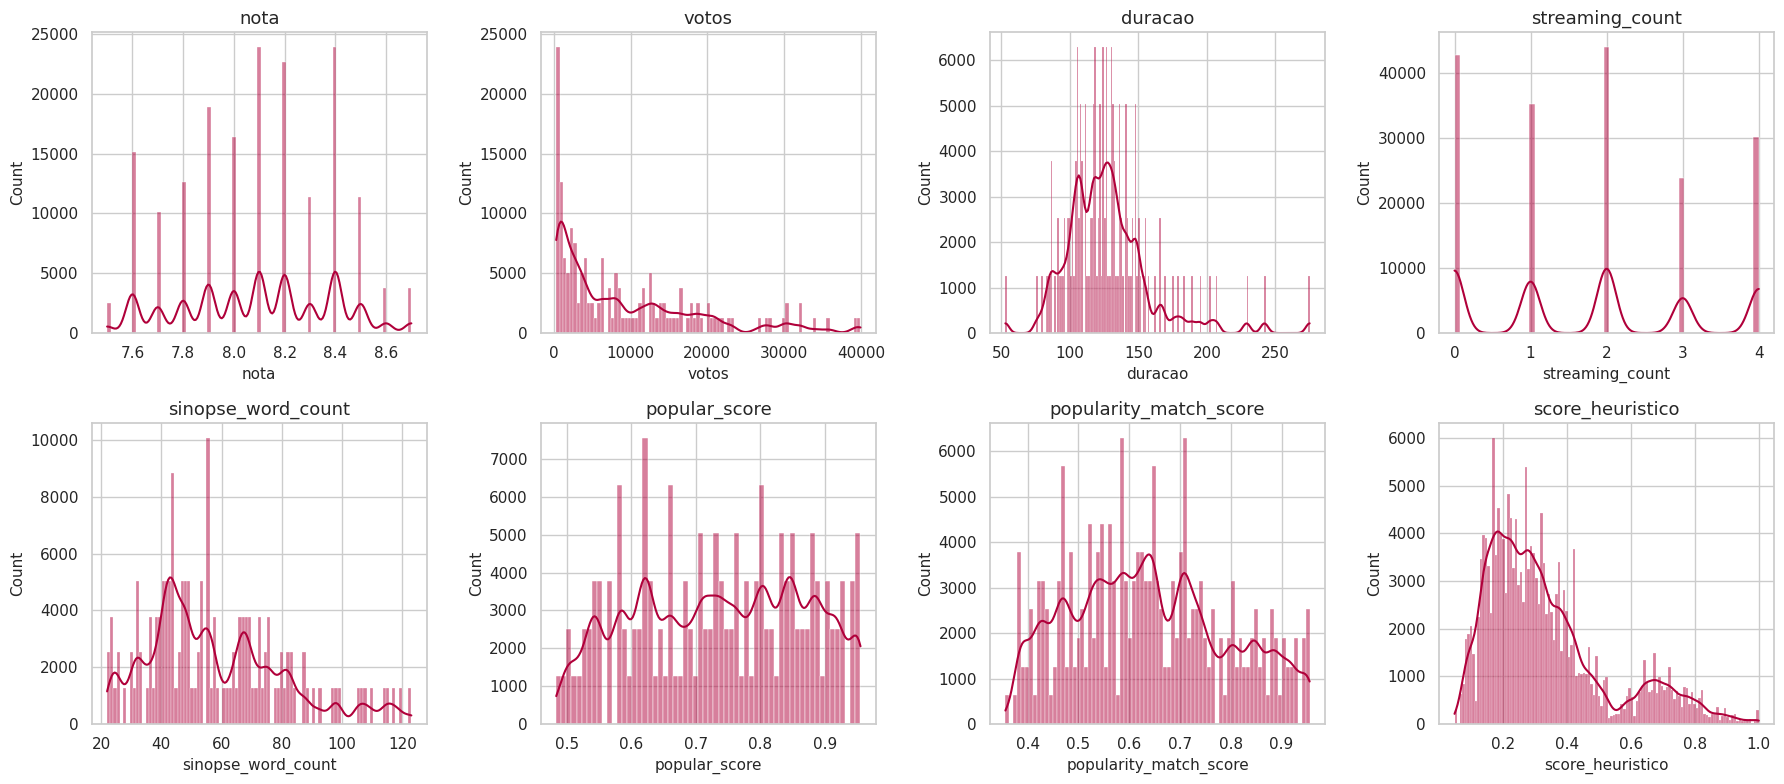

,count,mean,std,min,25%,50%,75%,max
nota,176400.0,8.089286,0.294400,7.5000,7.9000,8.10000,8.3000,8.7000
votos,176400.0,9380.921429,9488.277809,312.0000,1789.0000,6174.00000,14334.7500,39953.0000
duracao,176400.0,127.171429,31.206302,53.0000,107.7500,124.00000,141.0000,275.0000
streaming_count,176400.0,1.792857,1.396410,0.0000,1.0000,2.00000,3.0000,4.0000
sinopse_word_count,176400.0,58.328571,22.973168,22.0000,42.0000,53.00000,72.0000,123.0000
popular_score,176400.0,0.734414,0.129956,0.4833,0.6218,0.73905,0.8454,0.9553
popularity_match_score,176400.0,0.639024,0.151990,0.3560,0.5224,0.62920,0.7411,0.9553
score_heuristico,176400.0,0.335499,0.194006,0.0483,0.1928,0.28650,0.4137,1.0000


In [6]:
selected_numeric = [
    "nota",
    "votos",
    "duracao",
    "streaming_count",
    "sinopse_word_count",
    "popular_score",
    "popularity_match_score",
    "score_heuristico",
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for ax, col in zip(axes, selected_numeric):
    sns.histplot(df[col], kde=True, ax=ax, color="#b0003a")
    ax.set_title(col)

for ax in axes[len(selected_numeric):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

display(df[selected_numeric].describe().transpose())

### Leitura das distribuições numéricas

- `votos` apresenta **cauda longa**, o que é esperado em catálogo de filmes: poucos títulos concentram muito mais votação que a maioria.
- `duracao` também tem alguns valores altos, mas sem cair em valores impossíveis para o domínio.
- `nota` está bastante concentrada entre **7,5 e 8,7**, coerente com um catálogo já curado.
- `popular_score`, `popularity_match_score` e `score_heuristico` já nascem em escalas controladas, o que facilita a modelagem.
- Como `score_heuristico` participa da definição do alvo, ele é útil para auditoria, mas **não pode entrar como feature de treino**.

## 4. Distribuições das features categóricas selecionadas

Aqui o objetivo é verificar equilíbrio entre categorias, cardinalidade e possíveis gargalos de representação.

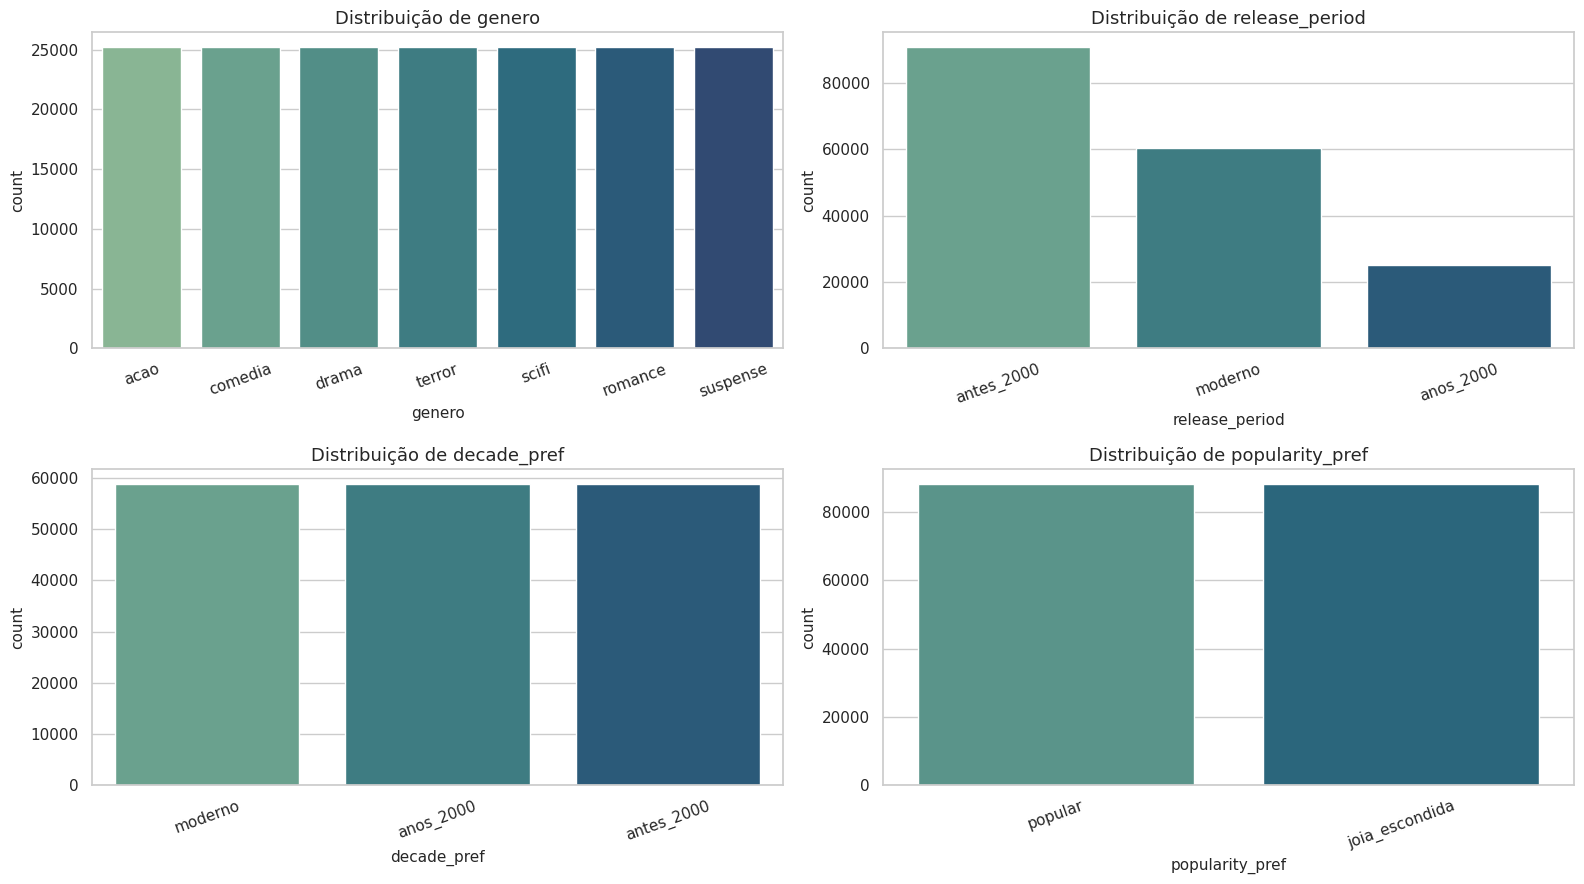

,coluna,n_categorias,categoria_mais_frequente
7,diretor,104,Alfred Hitchcock
0,genero,7,acao
2,pref_2,7,comedia
1,pref_1,7,acao
3,pref_3,7,drama
4,decade_pref,3,moderno
6,release_period,3,antes_2000
5,popularity_pref,2,popular


In [7]:
selected_categoricals = ["genero", "release_period", "decade_pref", "popularity_pref"]

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
axes = axes.flatten()

for ax, col in zip(axes, selected_categoricals):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=ax, palette="crest")
    ax.set_title(f"Distribuição de {col}")
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

cardinality = pd.DataFrame({
    "coluna": ["genero", "pref_1", "pref_2", "pref_3", "decade_pref", "popularity_pref", "release_period", "diretor"],
    "n_categorias": [
        df["genero"].nunique(),
        df["pref_1"].nunique(),
        df["pref_2"].nunique(),
        df["pref_3"].nunique(),
        df["decade_pref"].nunique(),
        df["popularity_pref"].nunique(),
        df["release_period"].nunique(),
        df["diretor"].nunique(),
    ],
    "categoria_mais_frequente": [
        df["genero"].value_counts().idxmax(),
        df["pref_1"].value_counts().idxmax(),
        df["pref_2"].value_counts().idxmax(),
        df["pref_3"].value_counts().idxmax(),
        df["decade_pref"].value_counts().idxmax(),
        df["popularity_pref"].value_counts().idxmax(),
        df["release_period"].value_counts().idxmax(),
        df["diretor"].value_counts().idxmax(),
    ],
}).sort_values("n_categorias", ascending=False)

display(cardinality)

### Interpretação das categóricas

- `genero`, `pref_1`, `pref_2` e `pref_3` têm cardinalidade baixa e controlada, o que favorece codificação com one-hot.
- `decade_pref` e `popularity_pref` estão **balanceadas por construção** do dataset, já que fazem parte das combinações geradas.
- `release_period` não está balanceada: há mais filmes anteriores a 2000 do que filmes dos anos 2000.
- `diretor` tem **cardinalidade alta** para o tamanho do catálogo (`104` categorias), então precisa de cuidado para não aumentar demais a dimensionalidade sem ganho proporcional.

## 5. Relações entre features e alvo

Foram escolhidas três visualizações complementares:

1. **Boxplot de `popularity_match_score` x alvo**: mostra se a aderência à popularidade ajuda a separar classes.
2. **Boxplot de `score_heuristico` x alvo**: serve como auditoria do proxy label e ajuda a identificar risco de leakage.
3. **Scatter de `votos` x `nota` por classe**: mostra se metadados gerais do filme, sozinhos, já separam suficientemente as classes.

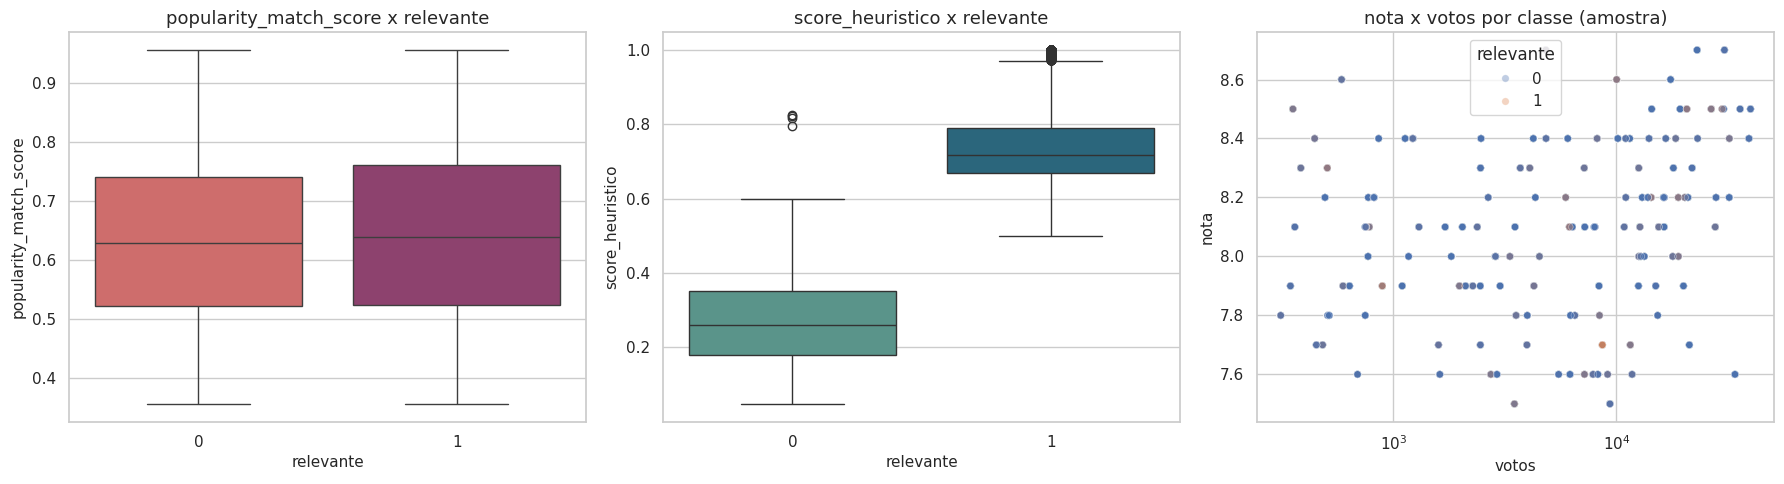

,taxa_positiva_percentual
primary_match_pref_1,
0,0.19
1,93.65


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df, x="relevante", y="popularity_match_score", ax=axes[0], palette="flare")
axes[0].set_title("popularity_match_score x relevante")

sns.boxplot(data=df, x="relevante", y="score_heuristico", ax=axes[1], palette="crest")
axes[1].set_title("score_heuristico x relevante")

sample_df = df.sample(min(8000, len(df)), random_state=42)
sns.scatterplot(
    data=sample_df,
    x="votos",
    y="nota",
    hue="relevante",
    alpha=0.35,
    s=28,
    ax=axes[2],
)
axes[2].set_xscale("log")
axes[2].set_title("nota x votos por classe (amostra)")

plt.tight_layout()
plt.show()

positive_rate_by_primary = (df.groupby("primary_match_pref_1")["relevante"].mean() * 100).round(2)
display(positive_rate_by_primary.rename("taxa_positiva_percentual").to_frame())

### Leitura das relações com o alvo

- `popularity_match_score` mostra separação, mas com bastante sobreposição entre as classes. Isso indica que popularidade ajuda, porém **não explica o alvo sozinha**.
- `score_heuristico` separa muito fortemente as classes, o que é esperado, já que o alvo `relevante` é derivado dele. Esse é justamente um **sinal de potencial leakage** caso a coluna entrasse como feature.
- No scatter de `nota` x `votos`, as classes ainda se misturam bastante, mostrando que metadados gerais do filme não bastam sozinhos para resolver a tarefa.
- A taxa positiva quando `primary_match_pref_1 = 1` é muito superior à taxa quando a preferência principal não bate, reforçando que os atributos de afinidade são o núcleo do problema.

## 6. Matriz de correlação das numéricas

A matriz abaixo usa apenas colunas numéricas relevantes para análise. Colunas identificadoras e constantes foram removidas dessa etapa.

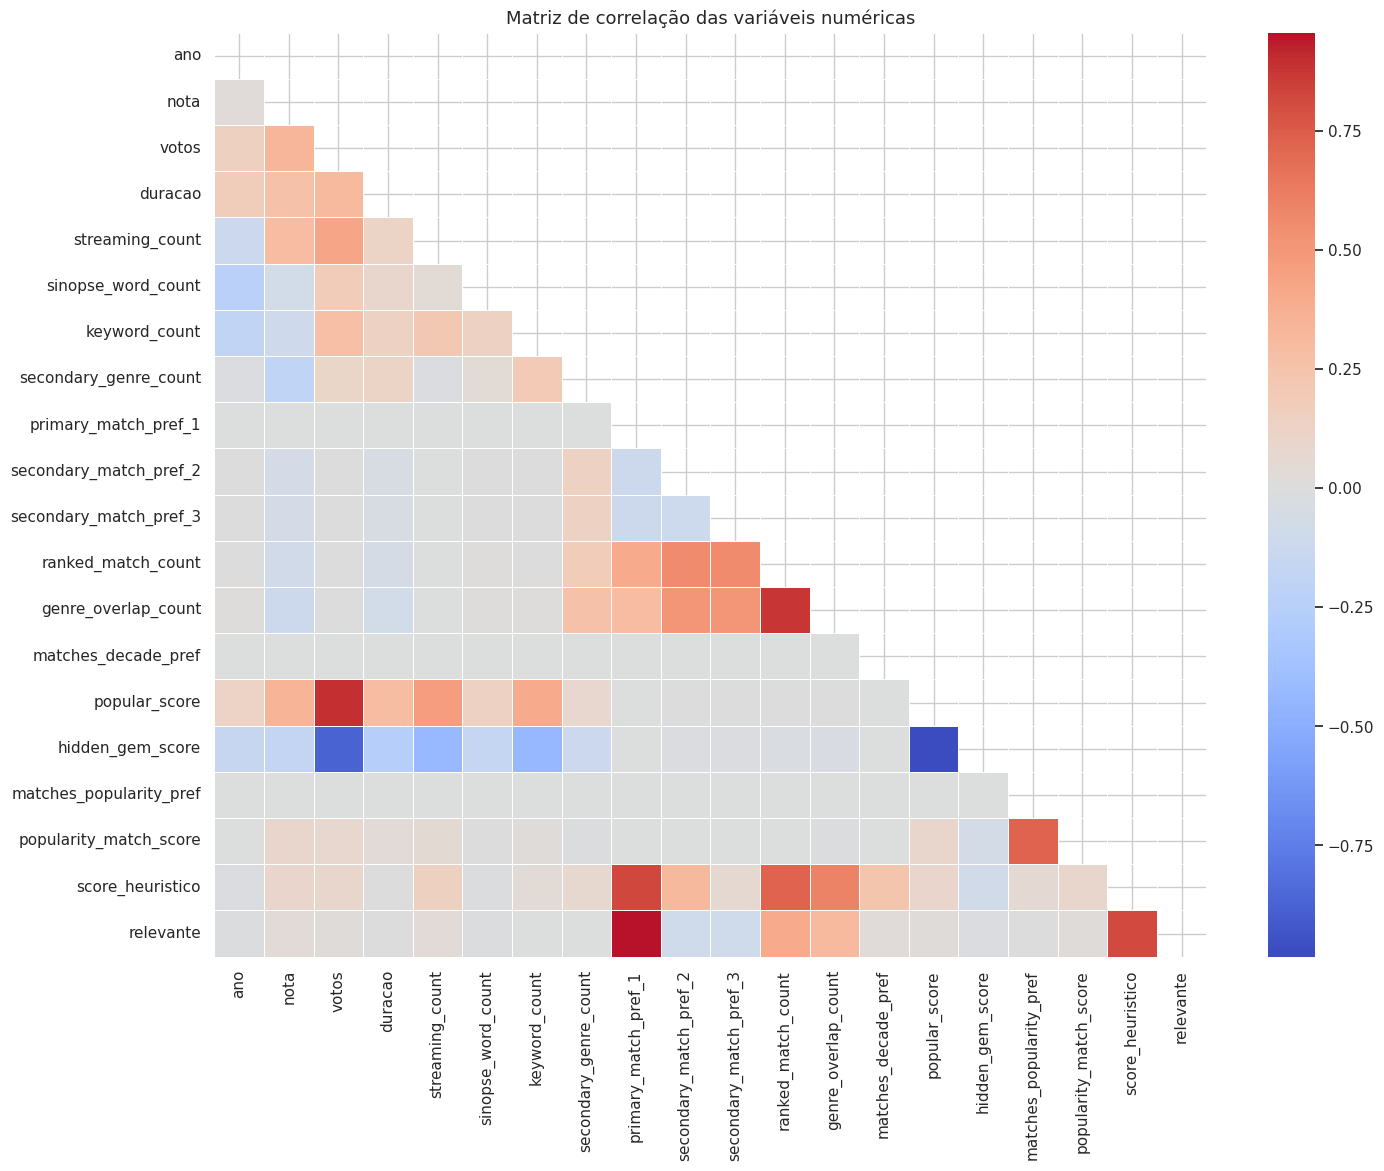

,coluna_1,coluna_2,correlacao
6,popular_score,hidden_gem_score,-0.9834
3,primary_match_pref_1,relevante,0.9558
0,votos,popular_score,0.8921
4,ranked_match_count,genre_overlap_count,0.8786
1,votos,hidden_gem_score,-0.8717
2,primary_match_pref_1,score_heuristico,0.8237
8,score_heuristico,relevante,0.8152
5,ranked_match_count,score_heuristico,0.7233
7,matches_popularity_pref,popularity_match_score,0.7225


In [9]:
numeric_for_corr = [
    "ano",
    "nota",
    "votos",
    "duracao",
    "streaming_count",
    "sinopse_word_count",
    "keyword_count",
    "secondary_genre_count",
    "primary_match_pref_1",
    "secondary_match_pref_2",
    "secondary_match_pref_3",
    "ranked_match_count",
    "genre_overlap_count",
    "matches_decade_pref",
    "popular_score",
    "hidden_gem_score",
    "matches_popularity_pref",
    "popularity_match_score",
    "score_heuristico",
    "relevante",
]

corr = df[numeric_for_corr].corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(16, 12))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0, annot=False, linewidths=0.5)
plt.title("Matriz de correlação das variáveis numéricas")
plt.show()

high_corr_pairs = []
for i, col_1 in enumerate(corr.columns):
    for col_2 in corr.columns[i + 1:]:
        value = corr.loc[col_1, col_2]
        if abs(value) >= 0.7:
            high_corr_pairs.append({
                "coluna_1": col_1,
                "coluna_2": col_2,
                "correlacao": round(float(value), 4),
            })

high_corr_df = pd.DataFrame(high_corr_pairs).sort_values("correlacao", key=lambda s: s.abs(), ascending=False)
display(high_corr_df)

### Interpretação das correlações fortes

Os pares com `|r| >= 0,7` merecem atenção:

- `popular_score` e `hidden_gem_score`: forte dependência porque os dois scores são derivados das mesmas bases de nota e votos.
- `ranked_match_count` e `genre_overlap_count`: medem conceitos muito próximos de sobreposição entre preferências e gêneros.
- `score_heuristico` e `primary_match_pref_1`: reforçam que o alvo proxy é fortemente guiado pela preferência principal.
- `popularity_match_score` e `matches_popularity_pref`: também capturam facetas relacionadas da mesma heurística.

Isso não impede o treino, mas indica **multicolinearidade** em parte das features derivadas. Em modelos lineares regularizados isso é administrável, mas precisa ser reconhecido.

## 7. Identificação de problemas nos dados

Esta seção consolida checagens de qualidade que realmente fazem sentido para a base atual: valores ausentes, duplicatas, constância, cardinalidade, outliers e valores impossíveis.

In [10]:
missing_summary = df.isnull().sum().sort_values(ascending=False)
duplicated_rows = int(df.duplicated().sum())
constant_columns = [col for col in df.columns if df[col].nunique(dropna=False) <= 1]
high_cardinality = {col: int(df[col].nunique()) for col in ["diretor"] if df[col].nunique() > 50}

impossible_checks = pd.DataFrame({
    "checagem": [
        "nota fora do intervalo [0, 10]",
        "votos negativos",
        "duração <= 0",
        "ano no futuro",
        "poster sem prefixo http",
        "url fora do domínio TMDB",
    ],
    "quantidade": [
        int(((df["nota"] < 0) | (df["nota"] > 10)).sum()),
        int((df["votos"] < 0).sum()),
        int((df["duracao"] <= 0).sum()),
        int((df["ano"] > pd.Timestamp.now().year).sum()),
        int((~df["poster"].fillna("").str.startswith("http")).sum()),
        int((~df["url"].fillna("").str.contains("themoviedb.org")).sum()),
    ],
})

def iqr_outlier_summary(frame, columns):
    rows = []
    for col in columns:
        q1 = frame[col].quantile(0.25)
        q3 = frame[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        mask = (frame[col] < lower) | (frame[col] > upper)
        rows.append({
            "coluna": col,
            "outliers_iqr": int(mask.sum()),
            "percentual": round(mask.mean() * 100, 2),
            "limite_inferior": round(float(lower), 3),
            "limite_superior": round(float(upper), 3),
        })
    return pd.DataFrame(rows).sort_values("outliers_iqr", ascending=False)

outlier_summary = iqr_outlier_summary(
    df,
    ["votos", "duracao", "sinopse_word_count", "keyword_count", "popular_score", "hidden_gem_score", "popularity_match_score"],
)

print("Colunas com nulos:")
display(missing_summary[missing_summary > 0].to_frame("nulos"))
print(f"Linhas duplicadas exatas: {duplicated_rows}")
print(f"Colunas constantes: {constant_columns}")
print(f"Colunas categóricas de alta cardinalidade: {high_cardinality}")

print("\nValores impossíveis ou malformados:")
display(impossible_checks)

print("\nResumo de outliers por IQR:")
display(outlier_summary)

Colunas com nulos:


,nulos


Linhas duplicadas exatas: 0
Colunas constantes: ['has_poster']
Colunas categóricas de alta cardinalidade: {'diretor': 104}

Valores impossíveis ou malformados:


,checagem,quantidade
0,"nota fora do intervalo [0, 10]",0
1,votos negativos,0
2,duração <= 0,0
3,ano no futuro,0
4,poster sem prefixo http,0
5,url fora do domínio TMDB,0



Resumo de outliers por IQR:


,coluna,outliers_iqr,percentual,limite_inferior,limite_superior
3,keyword_count,18900,10.71,6.000,6.000
1,duracao,8820,5.00,57.875,190.875
0,votos,5040,2.86,-17029.625,33153.375
2,sinopse_word_count,2520,1.43,-3.000,117.000
4,popular_score,0,0.00,0.286,1.181
5,hidden_gem_score,0,0.00,0.193,0.899
6,popularity_match_score,0,0.00,0.194,1.069


### Diagnóstico dos problemas encontrados

- **Valores ausentes**: não foram encontrados nulos na base supervisionada final.
- **Duplicatas exatas**: não foram encontradas linhas duplicadas.
- **Colunas constantes**: `has_poster` é constante, então não agrega poder discriminativo.
- **Cardinalidade alta**: `diretor` merece cuidado por ter muitas categorias em relação ao catálogo disponível.
- **Outliers**: os principais aparecem em `votos` e `duracao`, mas ambos são plausíveis no domínio e refletem distribuição real de catálogo.
- **Valores impossíveis**: não surgiram notas negativas, duração inválida ou anos futuros.

Observação importante: o caso de `keyword_count` no IQR é uma consequência da coluna ser muito concentrada em torno de `6`, então pequenas variações já são marcadas pelo critério estatístico. Isso não significa erro de dado.

## 8. Decisões de limpeza e preparo para modelagem

Cada decisão abaixo está ligada a um problema real identificado na análise.

In [11]:
decisions = pd.DataFrame([
    {
        "problema": "Valores ausentes",
        "decisao": "Nenhuma imputação necessária",
        "justificativa": "A base supervisionada final não apresentou nulos.",
    },
    {
        "problema": "Duplicatas exatas",
        "decisao": "Nenhuma remoção adicional",
        "justificativa": "Não há linhas duplicadas no CSV final; a deduplicação relevante já ocorreu no fluxo upstream.",
    },
    {
        "problema": "Identificadores e metadados operacionais",
        "decisao": "Excluir `movie_id`, `titulo`, `poster` e `url` do treino",
        "justificativa": "São colunas úteis para operação do bot, mas não generalizam afinidade do usuário.",
    },
    {
        "problema": "Leakage do alvo proxy",
        "decisao": "Excluir `score_heuristico` do treino",
        "justificativa": "O alvo `relevante` é derivado desse score; mantê-lo como feature inflaria artificialmente as métricas.",
    },
    {
        "problema": "Coluna constante `has_poster`",
        "decisao": "Remover em próxima iteração da feature space",
        "justificativa": "Como o valor é sempre 1, a coluna não contribui para separação entre classes.",
    },
    {
        "problema": "Alta cardinalidade em `diretor`",
        "decisao": "Manter com one-hot e monitorar dimensionalidade",
        "justificativa": "A cardinalidade ainda é administrável no baseline, mas pode justificar codificação alternativa em ciclos futuros.",
    },
    {
        "problema": "Outliers em `votos` e `duracao`",
        "decisao": "Preservar por enquanto",
        "justificativa": "São valores plausíveis do domínio e carregam informação útil sobre popularidade e perfil do catálogo.",
    },
    {
        "problema": "Risco de memorizar o mesmo filme",
        "decisao": "Separar treino e teste por `movie_id`",
        "justificativa": "A validação por grupos reduz leakage entre combinações diferentes do mesmo filme.",
    },
])

display(decisions)

,problema,decisao,justificativa
0,Valores ausentes,Nenhuma imputação necessária,A base supervisionada final não apresentou nulos.
1,Duplicatas exatas,Nenhuma remoção adicional,Não há linhas duplicadas no CSV final; a dedup...
2,Identificadores e metadados operacionais,"Excluir `movie_id`, `titulo`, `poster` e `url`...","São colunas úteis para operação do bot, mas nã..."
3,Leakage do alvo proxy,Excluir `score_heuristico` do treino,O alvo `relevante` é derivado desse score; man...
4,Coluna constante `has_poster`,Remover em próxima iteração da feature space,"Como o valor é sempre 1, a coluna não contribu..."
5,Alta cardinalidade em `diretor`,Manter com one-hot e monitorar dimensionalidade,A cardinalidade ainda é administrável no basel...
6,Outliers em `votos` e `duracao`,Preservar por enquanto,São valores plausíveis do domínio e carregam i...
7,Risco de memorizar o mesmo filme,Separar treino e teste por `movie_id`,A validação por grupos reduz leakage entre com...


## 9. Insights da EDA que guiam a modelagem

1. **A base é desbalanceada** (`13,54%` de classe positiva), então accuracy não pode ser a métrica principal.
2. **As features de afinidade são o sinal dominante**, especialmente a coincidência com a preferência principal.
3. **`score_heuristico` é útil para auditoria, mas é leakage para treino**, porque o alvo nasce a partir dele.
4. **Há multicolinearidade entre algumas features derivadas**, o que favorece modelos lineares regularizados e análise cuidadosa de variáveis correlacionadas.
5. **`has_poster` é constante e `diretor` tem alta cardinalidade**, então existe espaço para refino futuro da feature space.
6. **Os outliers observados são majoritariamente plausíveis no domínio**, logo não devem ser removidos de forma automática só por critério estatístico.

## Conclusão

A EDA mostra que o dataset está limpo do ponto de vista estrutural, mas exige atenção em três frentes de modelagem:

- desbalanceamento da classe alvo;
- risco de leakage por colunas auxiliares;
- correlação forte entre features derivadas da própria heurística.

Esses achados sustentam a estratégia atual do projeto: validação por grupos, comparação de múltiplos modelos, uso de métricas além de accuracy e exclusão de colunas operacionais ou potencialmente vazadoras.